# ML Practice: Linear & Logistic Regression

Companion notebook for the `ml_practice` MySQL database.

Run `ml_practice_db.sql` in MySQL Workbench **first**, then run the cells below in order.

**Structure (simple -> complex):**
1. Simple Linear Regression &rarr; `experience_salary`
2. Multiple Linear Regression &rarr; `advertising_sales`
3. Logistic Regression &rarr; `customer_churn`
4. YoY Projection (feature engineering) &rarr; `yearly_revenue`


## Setup

Uncomment the line below if you need to install packages.

In [1]:
# !pip install mysql-connector-python sqlalchemy pandas scikit-learn matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

%matplotlib inline

### Connection

Update credentials to match your MySQL Workbench connection.

In [2]:
DB_USER = "root"
DB_PASSWORD = "asd123456"
DB_HOST = "localhost"
DB_NAME = "ml_practice"

engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

# quick connectivity check
pd.read_sql("SHOW TABLES", engine)

,Tables_in_ml_practice
0,advertising_sales
1,customer_churn
2,experience_salary
3,products
4,v_yearly_revenue_totals
5,yearly_revenue


## 1. Simple Linear Regression

`experience_salary` — 1 feature (`years_experience`) &rarr; 1 target (`salary`).

This is the `model.fit(X, y)` / `model.predict([[6]])` pattern you started with.

In [3]:
df1 = pd.read_sql("SELECT years_experience, salary FROM experience_salary", engine)
df1.head()

,years_experience,salary
0,0.9,38739.51
1,1.4,37706.87
2,1.6,44187.63
3,1.8,38897.47
4,2.4,45706.59


In [4]:
X = df1[["years_experience"]]
y = df1["salary"]

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[6]])
print(f"Predicted salary at 6 years experience: {prediction[0]:,.2f}")
print(f"Coefficient (slope): {model.coef_[0]:,.2f}")
print(f"Intercept: {model.intercept_:,.2f}")
print(f"R^2 on training data: {model.score(X, y):.4f}")

Predicted salary at 6 years experience: 59,474.16
Coefficient (slope): 4,344.93
Intercept: 33,404.56
R^2 on training data: 0.9898


C:\Users\infop\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


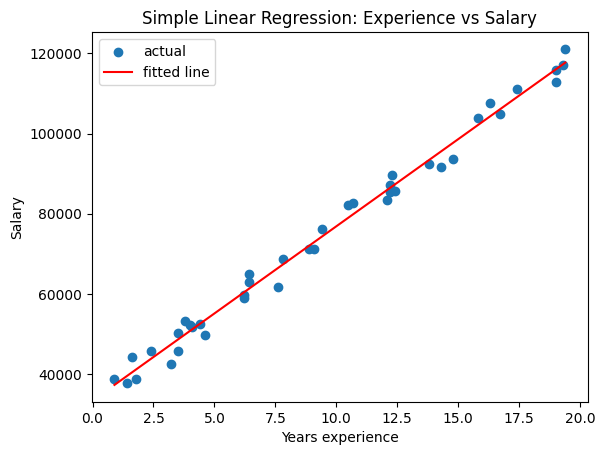

In [5]:
plt.scatter(df1["years_experience"], df1["salary"], label="actual")
plt.plot(df1["years_experience"], model.predict(X), color="red", label="fitted line")
plt.xlabel("Years experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression: Experience vs Salary")
plt.legend()
plt.show()

## 2. Multiple Linear Regression

`advertising_sales` — 3 features (`tv_spend`, `radio_spend`, `newspaper_spend`) &rarr; `sales`, with a proper train/test split.

In [6]:
df2 = pd.read_sql(
    "SELECT tv_spend, radio_spend, newspaper_spend, sales FROM advertising_sales",
    engine
)
df2.describe()

,tv_spend,radio_spend,newspaper_spend,sales
count,200.000000,200.000000,200.000000,200.000000
mean,152.322350,24.905900,48.448550,16.031850
std,87.752757,15.210859,28.914663,5.153294
min,1.520000,0.540000,1.450000,3.570000
25%,75.345000,11.082500,23.505000,12.465000
50%,155.570000,25.965000,46.620000,15.865000
75%,229.190000,37.685000,73.062500,19.920000
max,297.020000,49.650000,99.970000,28.330000


In [7]:
X = df2[["tv_spend", "radio_spend", "newspaper_spend"]]
y = df2["sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)
print("Coefficients (tv, radio, newspaper):", model2.coef_.round(4))
print(f"Intercept: {model2.intercept_:.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred) ** 0.5:.4f}")
print(f"R^2: {r2_score(y_test, y_pred):.4f}")

Coefficients (tv, radio, newspaper): [0.0458 0.1967 0.0108]
Intercept: 3.5979
RMSE: 1.3549
R^2: 0.9309


In [8]:
# example prediction: $150k TV, $20k radio, $10k newspaper spend
example = pd.DataFrame([[150, 20, 10]], columns=["tv_spend", "radio_spend", "newspaper_spend"])
print(f"Predicted sales for example spend: {model2.predict(example)[0]:.2f}")

Predicted sales for example spend: 14.51


## 3. Logistic Regression

`customer_churn` — mixed numeric + categorical features &rarr; binary target `is_churned`.

Uses a `Pipeline` with `OneHotEncoder` for `contract_type`.

In [12]:
df3 = pd.read_sql(
    """SELECT tenure_months, monthly_charges, total_charges,
              contract_type, support_calls, is_churned
       FROM customer_churn""",
    engine
)
df3.head()

,tenure_months,monthly_charges,total_charges,contract_type,support_calls,is_churned
0,37,22.21,752.29,Month-to-month,4,0
1,70,52.36,3582.93,Month-to-month,3,0
2,18,68.86,1290.61,One year,3,0
3,42,97.04,4197.67,Two year,2,0
4,41,88.33,3690.74,Month-to-month,1,0


In [13]:
X = df3.drop(columns=["is_churned"])
y = df3["is_churned"]

numeric_features = ["tenure_months", "monthly_charges", "total_charges", "support_calls"]
categorical_features = ["contract_type"]

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_features)],
    remainder="passthrough"
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7600
Confusion matrix:
 [[56  4]
 [14  1]]
Classification report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86        60
           1       0.20      0.07      0.10        15

    accuracy                           0.76        75
   macro avg       0.50      0.50      0.48        75
weighted avg       0.68      0.76      0.71        75



In [ ]:
# example: month-to-month customer, 3 months tenure, high monthly charge, 4 support calls
example = pd.DataFrame([{
    "tenure_months": 3,
    "monthly_charges": 95.0,
    "total_charges": 285.0,
    "contract_type": "Month-to-month",
    "support_calls": 4
}])
churn_prob = pipeline.predict_proba(example)[0][1]
print(f"Predicted churn probability for example customer: {churn_prob:.2%}")

## 4. YoY Revenue Projection

`yearly_revenue` — engineer a continuous `time_index` from `(yr, quarter)`, one-hot encode `region`, then project forward into 2026.

In [ ]:
df4 = pd.read_sql(
    "SELECT yr, quarter, region, marketing_spend, revenue FROM yearly_revenue",
    engine
)

df4["time_index"] = (df4["yr"] - df4["yr"].min()) * 4 + (df4["quarter"] - 1)
df4.head()

In [ ]:
X = df4[["time_index", "quarter", "region", "marketing_spend"]]
y = df4["revenue"]

preprocessor = ColumnTransformer(
    transformers=[("region_ohe", OneHotEncoder(drop="first"), ["region"])],
    remainder="passthrough"
)

pipeline4 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline4.fit(X_train, y_train)
y_pred = pipeline4.predict(X_test)

print(f"RMSE: {mean_squared_error(y_test, y_pred) ** 0.5:,.2f}")
print(f"R^2: {r2_score(y_test, y_pred):.4f}")

In [ ]:
# project next 4 quarters (2026) for the North region
next_time_index = df4["time_index"].max() + pd.Series([1, 2, 3, 4])
future = pd.DataFrame({
    "time_index": next_time_index,
    "quarter": [1, 2, 3, 4],
    "region": "North",
    "marketing_spend": df4.loc[df4["region"] == "North", "marketing_spend"].mean()
})
future_pred = pipeline4.predict(future)
for q, val in zip([1, 2, 3, 4], future_pred):
    print(f"Projected 2026 Q{q} revenue (North): {val:,.2f}")

In [ ]:
yearly_totals = df4.groupby("yr")["revenue"].sum()
plt.plot(yearly_totals.index, yearly_totals.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Total revenue")
plt.title("Total Revenue by Year (all regions)")
plt.show()

## Next steps to try

- Swap `LinearRegression` for `PolynomialFeatures` on the revenue data to capture the seasonal curve better.
- Add a `StandardScaler` step to the churn pipeline and compare `L1` vs `L2` regularization strength (`C`).
- Try `RidgeCV` / `LassoCV` on `advertising_sales` and compare coefficients to plain `LinearRegression`.
